Градиентный бустинг

1.	Подготовить и проанализировать набор данных для обучения модели. Провести очистку данных и их предобработку (обработка пропусков, нормализация/стандартизация, кодирование категориальных признаков). Если необходимо выполнить маштабирование данных. Можно использовать датасет, который был выбран для разведывательного анализа данных.
2.	Обучить модель градиентного бустинга на выбранных данных: создать модель случайного леса с исходными параметрами. Обучить модель на тренировочной части данных. Сделать прогнозы на тестовой части.
3.	Оценить качество модели с помощью метрик (accuracy, precision, recall, F1-score для классификации; MSE, RMSE, R² для регрессии).
4.	Визуализировать результаты (например, матрицу ошибок для классификации).
5.	Провести настройку гиперпараметров модели (число деревьев, глубина деревьев и т.п.).
6.	Использовать GridSearchCV для подбора оптимальных параметров.
7.	Повторить обучение и оценку с новыми параметрами.
8.	Исследовать влияние скорости обучения (learning_rate) и количества деревьев на качество модели.



0. Импорты

In [9]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier

import matplotlib.pyplot as plt

1. Загрузка и первичный анализ данных

In [10]:
df = pd.read_csv('diabetes.csv')

print("Первые строки датасета:")
print(df.head(), "\n")

print("Размерность датасета:", df.shape, "\n")

print("Описание числовых признаков:")
print(df.describe(), "\n")

print("Количество пропусков по столбцам (до обработки):")
print(df.isna().sum(), "\n")

print("Распределение целевой переменной (Outcome):")
print(df['Outcome'].value_counts(), "\n")

# В этом датасете принято считать нули в некоторых признаках «скрытыми пропусками»
cols_with_zero_as_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zero_as_missing] = df[cols_with_zero_as_missing].replace(0, np.nan)

print("Количество NaN после замены нулей на пропуски:")
print(df[cols_with_zero_as_missing].isna().sum(), "\n")


Первые строки датасета:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1   

Размерность датасета: (769, 9) 

Описание числовых признаков:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   769.000000  769.000000     769.000000     769.000000  769.000000   
mean      3.840052  120.897269      69.115735      20.509753   

2. Подготовка признаков, разбиение, пайплайн с градиентным бустингом

In [11]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Все признаки числовые
numeric_features = X.columns.tolist()

# Пайплайн предобработки: заполнение пропусков + стандартизация
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ]
)

# Базовая модель градиентного бустинга
gb_clf = GradientBoostingClassifier(random_state=42)

baseline_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', gb_clf)
    ]
)

# Обучение базовой модели
baseline_pipeline.fit(X_train, y_train)

# Прогнозы на тесте
y_pred = baseline_pipeline.predict(X_test)


3. Метрики качества базовой модели

In [12]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=== Базовая модель GradientBoostingClassifier ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}\n")

print("Classification report (базовая модель):")
print(classification_report(y_test, y_pred))

=== Базовая модель GradientBoostingClassifier ===
Accuracy : 0.7727
Precision: 0.6727
Recall   : 0.6852
F1-score : 0.6789

Classification report (базовая модель):
              precision    recall  f1-score   support

           0       0.83      0.82      0.82       100
           1       0.67      0.69      0.68        54

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



 4. Визуализация: матрица ошибок



Матрица ошибок (базовая модель):
[[82 18]
 [17 37]] 



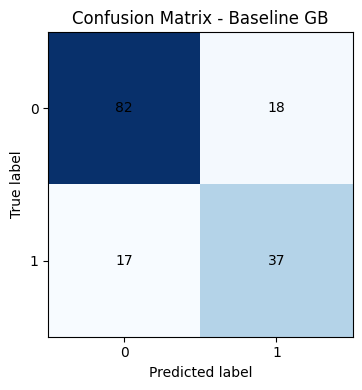

In [13]:
cm = confusion_matrix(y_test, y_pred)
print("Матрица ошибок (базовая модель):")
print(cm, "\n")

plt.figure(figsize=(4, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - Baseline GB")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks([0, 1], ['0', '1'])
plt.yticks([0, 1], ['0', '1'])

# Подписи чисел внутри клеток
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


5–6. Подбор гиперпараметров через GridSearchCV

In [14]:
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth': [1, 2, 3],
    'classifier__subsample': [0.8, 1.0],
}

grid_search = GridSearchCV(
    estimator=baseline_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1',     # оптимизируем F1, можно указать другую метрику
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Лучшие параметры по GridSearchCV:")
print(grid_search.best_params_)
print(f"Лучший средний F1 на кросс-валидации: {grid_search.best_score_:.4f}\n")

best_model = grid_search.best_estimator_

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Лучшие параметры по GridSearchCV:
{'classifier__learning_rate': 0.1, 'classifier__max_depth': 2, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}
Лучший средний F1 на кросс-валидации: 0.6233



7. Оценка модели с подобранными гиперпараметрами

=== Модель с оптимальными гиперпараметрами (GridSearchCV) ===
Accuracy : 0.7532
Precision: 0.6538
Recall   : 0.6296
F1-score : 0.6415

Classification report (лучшая модель):
              precision    recall  f1-score   support

           0       0.80      0.82      0.81       100
           1       0.65      0.63      0.64        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154

Матрица ошибок (лучшая модель):
[[82 18]
 [20 34]] 



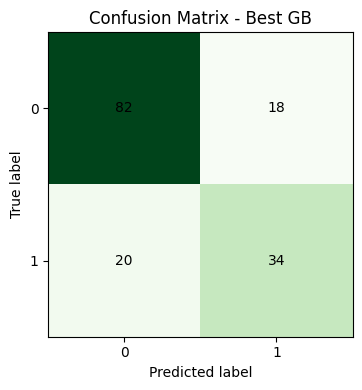

In [15]:
y_pred_best = best_model.predict(X_test)

acc_b = accuracy_score(y_test, y_pred_best)
prec_b = precision_score(y_test, y_pred_best)
rec_b = recall_score(y_test, y_pred_best)
f1_b = f1_score(y_test, y_pred_best)

print("=== Модель с оптимальными гиперпараметрами (GridSearchCV) ===")
print(f"Accuracy : {acc_b:.4f}")
print(f"Precision: {prec_b:.4f}")
print(f"Recall   : {rec_b:.4f}")
print(f"F1-score : {f1_b:.4f}\n")

print("Classification report (лучшая модель):")
print(classification_report(y_test, y_pred_best))

cm_b = confusion_matrix(y_test, y_pred_best)
print("Матрица ошибок (лучшая модель):")
print(cm_b, "\n")

plt.figure(figsize=(4, 4))
plt.imshow(cm_b, cmap="Greens")
plt.title("Confusion Matrix - Best GB")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks([0, 1], ['0', '1'])
plt.yticks([0, 1], ['0', '1'])

for i in range(cm_b.shape[0]):
    for j in range(cm_b.shape[1]):
        plt.text(j, i, cm_b[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

8. Влияние learning_rate и n_estimators

Влияние learning_rate и n_estimators на F1:
n_estimators        50        100       200       300
learning_rate                                        
0.01           0.410959  0.555556  0.613861  0.627451
0.05           0.607843  0.627451  0.654206  0.660377
0.10           0.647619  0.678899  0.660550  0.654206
0.20           0.634615  0.628571  0.635514  0.660550 



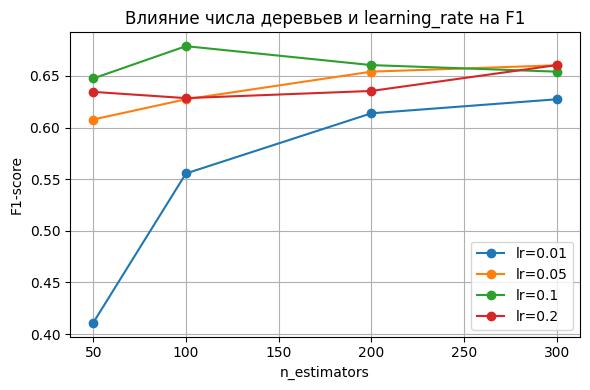

In [16]:
learning_rates = [0.01, 0.05, 0.1, 0.2]
n_estimators_list = [50, 100, 200, 300]

results = []

for lr in learning_rates:
    for n_est in n_estimators_list:
        clf = GradientBoostingClassifier(
            learning_rate=lr,
            n_estimators=n_est,
            random_state=42
        )
        pipe = Pipeline(
            steps=[
                ('preprocessor', preprocessor),
                ('classifier', clf)
            ]
        )
        pipe.fit(X_train, y_train)
        y_pred_lr = pipe.predict(X_test)
        f1_lr = f1_score(y_test, y_pred_lr)
        acc_lr = accuracy_score(y_test, y_pred_lr)
        results.append({
            'learning_rate': lr,
            'n_estimators': n_est,
            'F1': f1_lr,
            'Accuracy': acc_lr
        })

results_df = pd.DataFrame(results)
print("Влияние learning_rate и n_estimators на F1:")
print(results_df.pivot(index='learning_rate', columns='n_estimators', values='F1'), "\n")

# Можно также построить простые графики зависимости F1 от числа деревьев для разных learning_rate
plt.figure(figsize=(6, 4))
for lr in learning_rates:
    subset = results_df[results_df['learning_rate'] == lr].sort_values('n_estimators')
    plt.plot(subset['n_estimators'], subset['F1'], marker='o', label=f'lr={lr}')
plt.xlabel('n_estimators')
plt.ylabel('F1-score')
plt.title('Влияние числа деревьев и learning_rate на F1')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
